## ML Project (MID SEM)

We start by importing all the required libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Reading the dataset

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Basic Analysis of Dataset

In [ ]:
# data on all features
df.info()

In [ ]:
# statistics of all features
df.describe()

### Checking for null values

In [3]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

We can see that Teacher_Quality,Parental_Education_Level,Distance_from_Home columns have null values all are categorical columns so we will replace by mode

In [ ]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']: 
        mean_value = df[col].mean()
        df[col].fillna(mean_value, inplace=True)
    else: 
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
df.isnull().sum()


Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [ ]:
df.describe()

### Checking existence of duplicates:

In [5]:
df = df.drop_duplicates()
df.shape

(6607, 20)

In [ ]:
num_cols=[col for col in df.columns if df[col].dtype in ['int64', 'float64']]

### Outlier Detection and Removal

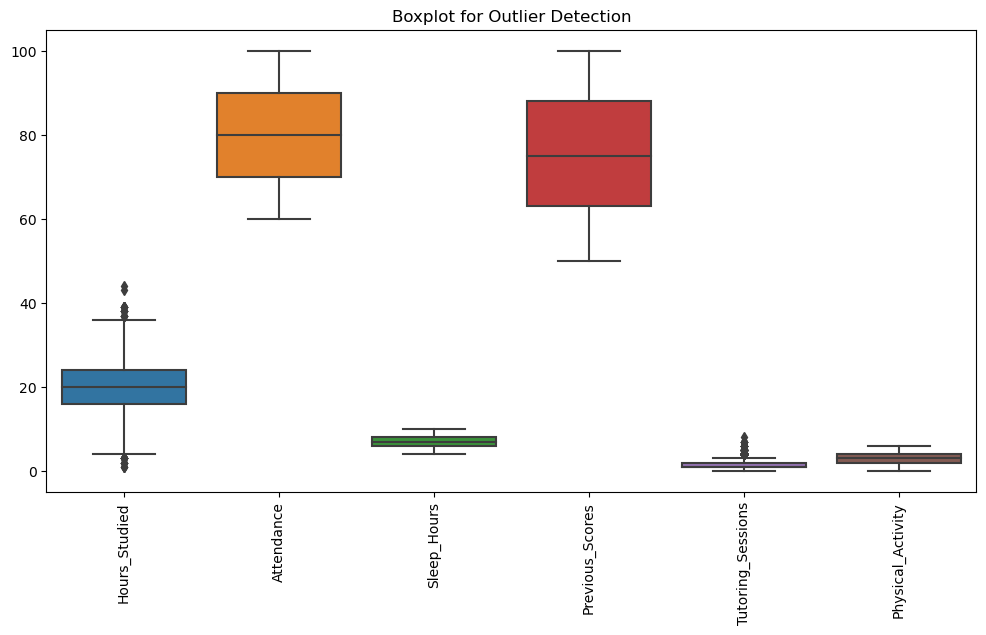

In [ ]:
plt.figure(figsize=(12,6))
cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col != 'Exam_Score']
sns.boxplot(data=df[cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

We notice a few outliers in the boxplot. Since the outliers are quite far away from the IQR, they can be removed.

In [ ]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

ol = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR)))
ol_iqr = ol.any(axis=1)
print(f'No. of outliers: {np.sum(ol_iqr)}')
df = df[~ol_iqr]

In [ ]:
plt.figure(figsize=(12,6))
cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col != 'Exam_Score']
sns.boxplot(data=df[cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

### Exploratory Data Analysis

#### Univariate Analysis

#### Numerical Features

In [ ]:
colors = ['k', 'r', 'c', 'g']
num_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col not in ['Tutoring_Sessions','Physical_Activity','Sleep_Hours'] ]
plt.figure(figsize=(20, 25))
for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i + 1)
    plt.title(' '.join(col.split('_')).title())
    sns.histplot(df[col], kde=True, color=colors[i % len(colors)])
plt.show()

In [ ]:
import math

colors = ['k', 'g', 'r', 'c']
cat_cols = ['Tutoring_Sessions','Physical_Activity','Sleep_Hours']
n_cols = 2 
n_rows = math.ceil(len(cat_cols) / n_cols) 

plt.figure(figsize=(15, n_rows * 5)) 

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.title(' '.join(col.split('_')).title())
    sns.countplot(x=df[col], color=colors[i % len(colors)])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Categorical Features

In [ ]:
colors = ['k', 'g', 'r', 'c']
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
n_cols = 2 
n_rows = math.ceil(len(cat_cols) / n_cols) 

plt.figure(figsize=(15, n_rows * 5)) 

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.title(' '.join(col.split('_')).title())
    sns.countplot(x=df[col], color=colors[i % len(colors)])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### Distribution of classes of Target

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Exam_Score'], kde=True, color='skyblue', bins=20)
plt.title('Distribution of Exam Score')
plt.xlabel('Exam_Score')
plt.ylabel('Frequency')
plt.show()


#### Bivariate Analysis

#### Numerical Features

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('Exam_Score')  # remove target

plt.figure(figsize=(15, len(num_cols)*4))

for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols), 1, i + 1)
    sns.scatterplot(x=df[col], y=df['Exam_Score'])
    plt.title(f'{col} vs Exam Score')
    plt.xlabel(col)
    plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()


#### Categorical Features

In [ ]:
palette = 'Set2'

n_cols = 1
n_rows = math.ceil(len(cat_cols) / n_cols)

plt.figure(figsize=(15, n_rows * 5))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.violinplot(x=col, y='Exam_Score', data=df, palette=palette)
    plt.title(" ".join(col.split('_')).title())
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", len(cat_cols))
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print("Numerical Columns:", len(num_cols))
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Categorical Columns: 13
Numerical Columns: 7


#### Multivariate Analysis

We plot the heatmap for the dataset to see the correlation between features

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

we are selecting all the features as maximum correlation is 0.58

In [ ]:
# standardization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
for col in num_cols:
    df[col] = sc.fit_transform(df[col].values.reshape(-1, 1))
df.head()

C:\Users\kedik\AppData\Local\Temp\ipykernel_4076\738233289.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data[col] = sc.fit_transform(clean_data[col].values.reshape(-1, 1))
C:\Users\kedik\AppData\Local\Temp\ipykernel_4076\738233289.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data[col] = sc.fit_transform(clean_data[col].values.reshape(-1, 1))
C:\Users\kedik\AppData\Local\Temp\ipykernel_4076\738233289.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,0.516070,0.350283,1,0,0,-0.023377,-0.147117,1,1,-1.314932,1,2,1,2,0.037064,0,1,2,1,0.005736
1,-0.176485,-1.389206,1,2,0,0.657031,-1.122403,1,1,0.718426,2,2,1,0,1.008430,0,0,1,0,-1.854632
2,0.689209,1.567925,2,2,1,-0.023377,1.106823,2,1,0.718426,2,2,1,1,1.008430,0,2,2,1,2.176166
3,1.554902,0.785155,1,2,1,0.657031,1.594466,2,1,-0.298253,2,2,1,0,1.008430,0,1,1,1,1.245982
4,-0.176485,1.046078,2,2,1,-0.703785,-0.704423,2,1,1.735105,2,0,1,1,1.008430,0,0,2,0,0.935920


## MODEL TRAINING

In [ ]:
X = df.drop('Exam_Score',axis=1)
y = df['Exam_Score']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection  import cross_val_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred)}")
cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

#### Actual v/s Predicted

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linewidth=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Test Set)")
plt.show()

The points do not lie exactly on the diagonal line. We can see that there is vertical spread across the diagonal line, the error is also consistent with the trend and spread is higher for larger values, but we can say that this model fits the data reasonably well the model. It is not perfect but it is an acceptable model.

### Polynomial Regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(5)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [ ]:
plr = LinearRegression()
plr.fit(X_train_poly, y_train)

y_train_pred = plr.predict(X_train_poly)
y_test_pred = plr.predict(X_test_poly)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred)}")
cv_scores = cross_val_score(plr, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

#### Hyperparameter Tuning

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('poly', PolynomialFeatures()), 
    ('linear', LinearRegression()) 
])

param_grid = {
    'poly__degree': np.arange(1, 6),
}

gscv = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='r2', cv=5, verbose=1, n_jobs=-1)
gscv.fit(X_train, y_train)

print(f"Best parameters found: {gscv.best_params_}")
print(f"Best score: {gscv.best_score_}")
best_poly_model = gscv.best_estimator_

test_r2 = best_poly_model.score(X_test, y_test)
test_pred = best_poly_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"Test R2: {test_r2}")
print(f"Test RMSE: {test_rmse}")

#### Learning Curve

In [ ]:
from sklearn.model_selection import learning_curve

best_params = best_poly_model.get_params()
best_degree = best_params['poly__degree']   

poly_final = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('linear', LinearRegression())
])

train_sizes, train_scores, test_scores = learning_curve(estimator=poly_final, X=X_train, y=y_train, cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1, verbose=1)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Training R2')
plt.plot(train_sizes, test_mean, marker='s', label='Validation R2')

plt.title(f"Learning Curve for Tuned Polynomial Regression (Degree = {best_degree})")
plt.xlabel("Training Samples")
plt.ylabel("R2 Score")
plt.grid(True)
plt.legend()
plt.show()

#### Actual v/s Predicted

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test,test_predictions)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()],
         linewidth=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Best Polynomial Model)")
plt.show()

Polynomial Regression is fitting the pattern better than linear Regression as we can see that the predictions are more accurate than before. But it is slightly overfitting. However, the overall performance is good. The hyperparameter tuning has improved the model very significantly, the new model is extremely accurate.

### LASSO

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(X_train, y_train)

y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred)}")
cv_scores = cross_val_score(lasso, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

#### Hyperparameter Tuning

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Hyperparameter grid
param_grid = {
    'alpha': np.logspace(-4, 2, 20)   # 0.0001 → 100
}

# GridSearchCV
grid = GridSearchCV(
    estimator=Lasso(max_iter=5000),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV R2 score:", grid.best_score_)

# Best model
best_lasso = grid.best_estimator_

# Predictions
y_train_pred = best_lasso.predict(X_train)
y_test_pred = best_lasso.predict(X_test)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

#### Actual v/s Predicted

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linewidth=2)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Lasso Regression: Actual vs Predicted")
plt.show()

We can say that the LASSO model has improved after tuning but still it is not perfect.

### Ridge

In [ ]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error for test:", mse)
print("R2 Score for test:", r2)
cv_scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

#### Hyperparameter Tuning

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Hyperparameter grid
param_grid = {
    'alpha': np.logspace(-4, 3, 50)   # 0.0001 → 1000
}

# GridSearchCV
grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV R2 score:", grid.best_score_)

# ---- Best model ----
best_ridge = grid.best_estimator_

y_train_pred = best_ridge.predict(X_train)
y_test_pred = best_ridge.predict(X_test)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

#### Actual v/s Predicted

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Ridge Regression)")
plt.show()

This model is a good model, it captures the trend well but withsome moderate errors.

### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred)}")
cv_scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

#### Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [None] + list(np.arange(1, 20)), 
    'min_samples_split': np.arange(2, 50),       
    'min_samples_leaf': np.arange(1, 25),        
    'max_features': ['auto', 'sqrt', 'log2', None] 
}

dt = DecisionTreeRegressor(random_state=42)

rscv = RandomizedSearchCV(estimator=dt, param_distributions=param_dist, n_iter=50,  cv=5, scoring='r2')

rscv.fit(X_train, y_train)

print(f"Best parameters: {rscv.best_params_}")
print(f"Best cross-validation R2 score: {rscv.best_score_}")
best_dt_model = rscv.best_estimator_
train_r2 = best_dt_model.score(X_train, y_train)
test_r2 = best_dt_model.score(X_test, y_test)

print(f"Train R2: {train_r2}")
print(f"Test R2: {test_r2}")

#### Hyperparameter Tuning

In [ ]:
# ------------------------
# Plot: Actual vs Predicted
# ------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
         linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree Regression\nActual vs Predicted (Tuned Model)")
plt.show()

It performs reasonably well but not it is the best model for this dataset.

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred)}")
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

#### Hyperparameter Tuning

In [ ]:
rf_param_dist = {'n_estimators': np.arange(50, 500, 50), 'max_depth': [None] + list(np.arange(3, 15)), 'min_samples_split': np.arange(2, 20), 'min_samples_leaf': np.arange(1, 10),'max_features': ['sqrt', 'log2', 1.0],'bootstrap': [True, False]}

rf = RandomForestRegressor(random_state=42)

rscv = RandomizedSearchCV(estimator=rf, param_distributions=rf_param_dist, n_iter=100, cv=5, scoring='r2', verbose=1, random_state=42, n_jobs=-1)

rscv.fit(X_train, y_train)

print(f"Best RF parameters: {rscv.best_params_}")
print(f"Best RF cross-validation R2 score: {rscv.best_score_}")
best_rf_model = rscv.best_estimator_

train_r2 = best_rf_model.score(X_train, y_train)
test_r2 = best_rf_model.score(X_test, y_test)

test_pred = best_rf_model.predict(X_test)
test_rmse = mean_squared_error(y_test, test_pred, squared=False)

print(f"Train R2: {train_r2}")
print(f"Test R2: {test_r2}")
print(f"Test RMSE: {test_rmse}")

#### Hyperparameter Tuning

In [ ]:
import matplotlib.pyplot as plt

# Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, test_predictions, alpha=0.6)
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    linestyle='--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression\nActual vs Predicted (Tuned Model)")
plt.grid(True)
plt.show()

It performs very well and also captures most of the variations in the data and make accurate predictions overall. It is a good and reliable model for this dataset.

#### Learning Curve

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(estimator=best_rf_model , X=X_train, y=y_train, cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1, verbose=1)


train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)


plt.plot(train_sizes, train_mean, marker='o', label='Training R2')
plt.plot(train_sizes, test_mean, marker='s', label='Validation R2')

plt.title("Learning Curve for Random Forest")
plt.xlabel("Training Samples")
plt.ylabel("R2 Score")
plt.grid(True)
plt.legend()
plt.show()

### SVR

In [ ]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)

y_train_pred = svr.predict(X_train)
y_test_pred = svr.predict(X_test)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred)}")
cv_scores = cross_val_score(svr, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

r2 score for train: 0.99
r2 score for test: 0.98
mse score for train: 0.01
mse score for test: 0.02


#### Hyperparameter Tuning

In [ ]:
from scipy.stats import reciprocal, uniform

svr_param_dist = {
    'kernel': ['rbf'],
    'C': reciprocal(0.1, 1000),  
    'gamma': reciprocal(0.001, 1),
    'epsilon': uniform(0.01, 1)
}

svr = SVR()

svr_random_search = RandomizedSearchCV(estimator=svr, param_distributions=svr_param_dist, n_iter=50, cv=5, scoring='r2', verbose=1, random_state=42, n_jobs=-1)

svr_random_search.fit(X_train, y_train) 

print(f"Best SVR parameters: {svr_random_search.best_params_}")
print(f"Best SVR R2 score: {svr_random_search.best_score_}")
best_svr_model = svr_random_search.best_estimator_

train_r2 = best_svr_model.score(X_train, y_train)
test_r2 = best_svr_model.score(X_test, y_test)
test_pred = best_svr_model.predict(X_test)
test_rmse = mean_squared_error(y_test, test_pred, squared=False)

print(f"SVR Train R2: {train_r2}")
print(f"SVR Test R2: {test_r2}")
print(f"SVR Test RMSE: {test_rmse}")

#### Predicted v/s Actual

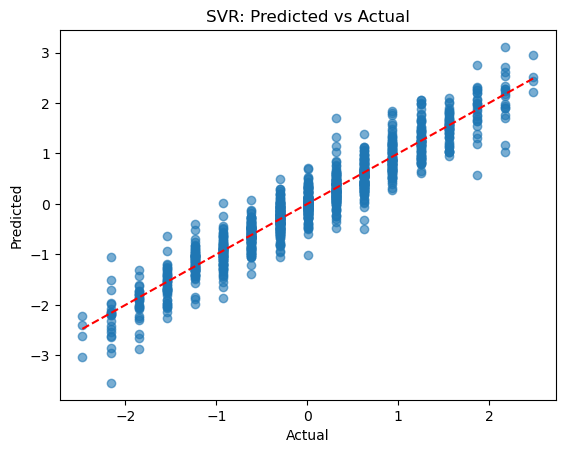

In [ ]:
plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("SVR- Predicted vs Actual")
plt.show()

#### Residual Plot

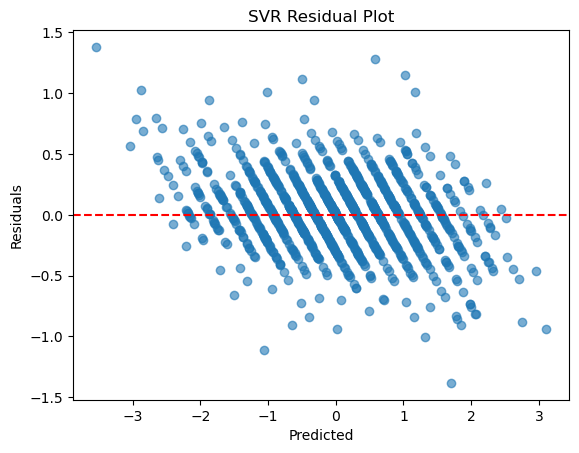

In [ ]:
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals)
# TODO
# plt.plot(np.linspace(y_test_pred.min(), y_test_pred.max(), 100), np.zeros(100))
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("SVR- Residual Plot")
plt.show()


#### Learning Curve

In [ ]:
from sklearn.model_selection import learning_curve

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', best_svr_model)
])

train_sizes, train_scores, test_scores = learning_curve(estimator=pipeline, X=X_train, y=y_train, cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1, verbose=1)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training R2')
plt.plot(train_sizes, test_mean, marker='s', label='Validation R2')
plt.title("Learning Curve of Tuned SVR Model")
plt.xlabel("Training Samples")
plt.ylabel("R2 Score")
plt.grid(True)
plt.legend()
plt.show()

### Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)

y_train_pred = gbr.predict(X_train)
y_test_pred = gbr.predict(X_test)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc}")
print(f"r2 score for test: {test_acc}")
print(f"mse for train: {mean_squared_error(y_train, y_train_pred)}")
print(f"mse for test: {mean_squared_error(y_test, y_test_pred)}")
cv_scores = cross_val_score(gbr, X_train, y_train, cv=5, scoring='r2')
print(f"CV scores:{cv_scores}")
print(f"Average CV score:{cv_scores.mean()}")

r2 score for train: 0.96
r2 score for test: 0.93
mse score for train: 0.04
mse score for test: 0.06


#### Hyperparameter Tuning

In [ ]:
gbr_param_dist = {
    'n_estimators': np.arange(100, 1000, 100),
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3], 
    'max_depth': np.arange(3, 8),
    'min_samples_split': np.arange(2, 20),
    'min_samples_leaf': np.arange(1, 10),
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}
gbr = GradientBoostingRegressor(random_state=42)

gbr_random_search = RandomizedSearchCV(estimator=gbr, param_distributions=gbr_param_dist, n_iter=50, cv=5, scoring='r2', random_state=42, n_jobs=-1)

gbr_random_search.fit(X_train, y_train)

print(f"Best GBR parameters: {gbr_random_search.best_params_}")
print(f"Best GBR R2 score: {gbr_random_search.best_score_}")
best_gbr_model = gbr_random_search.best_estimator_

test_predictions_tuned = best_gbr_model.predict(X_test)

tuned_r2 = r2_score(y_test, test_predictions_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, test_predictions_tuned))

print(f"GBR Test R2: {r2}")
print(f"GBR Test RMSE: {tuned_rmse}")

#### Actual v/s Predicted

In [ ]:
import matplotlib.pyplot as plt

# Predictions already computed:
# test_predictions_tuned = best_gbr_model.predict(X_test_r)

plt.figure(figsize=(6,6))
plt.scatter(y_test, test_predictions_tuned)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted Values")
plt.title("Tuned GradientBoostingRegressor: True vs Predicted")
plt.show()

This model works extremely well, the model fits the data almost perfectly.

### Adaboost

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Initialize AdaBoost
ada = AdaBoostRegressor(
    n_estimators=100, 
    learning_rate=0.1,
    random_state=42
)

# Fit model
ada.fit(X_train_r, y_train)

# Predict
y_train_pred = ada.predict(X_train_r)
y_test_pred = ada.predict(X_test_r)

# Manual evaluation (NO .score())
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Train R²:", train_r2)
print("Test R²:", test_r2)
print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

#### Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

ada = AdaBoostRegressor(random_state=42)

param_dist = {
    'n_estimators': np.arange(50, 500, 50),
    'learning_rate': np.linspace(0.01, 1.0, 20),
    'loss': ['linear', 'square', 'exponential']
}

ada_random = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit search
ada_random.fit(X_train_r, y_train)

print("Best Params:", ada_random.best_params_)
print("Best CV R2:", ada_random.best_score_)

# Best model
best_ada = ada_random.best_estimator_

# Predict
y_test_pred = best_ada.predict(X_test_r)

test_r2 = r2_score(y_test, y_test_pred)
test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

print("Test R2 (Tuned):", test_r2)
print("Test RMSE (Tuned):", test_rmse)

#### Actual v/s Predicted

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Tuned AdaBoost Regressor: True vs Predicted")
plt.show()

It also gives good performance and captures most of the patterns in the data but it is not that of a strong model.

### Important Features

Since SVR does so well (as per R2 Score), we try to see which features are most important with permutation_importance.

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf_model, X_test, y_test, scoring='r2', n_repeats=10, random_state=42)

importances = result.importances_mean
indices = np.argsort(importances)[::-1]

print("Feature importances:")
for i in indices:
    print(f"{X_train.columns[i]}: {importances[i]}")

plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X_train.columns[indices], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Feature importance')
plt.title("Permutation Feature Importance - SVR")
plt.show()

In [ ]:
# TODO: Feature importances for RF

In [ ]:
feat_imp = best_rf_model.feature_importances_
print(feat_imp)